In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.tools import *

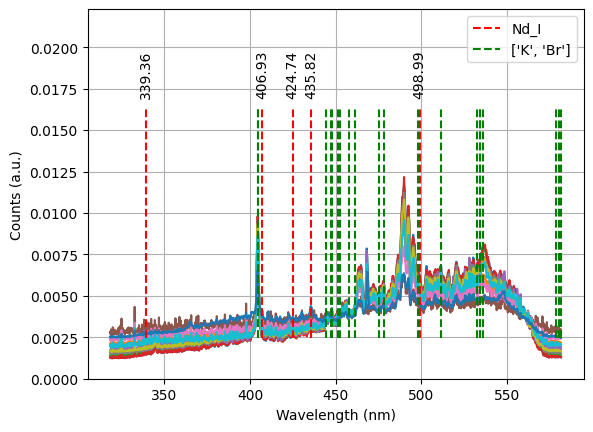

In [40]:
root = os.getcwd()
method = "Wavelength Scan"
date = "8_13"
atom = "Nd_I"
binders = ["K", "Br"]
top_n_lines = 5
pixel_to_wavelength = True

path = os.path.join(root, method)
path = os.path.join(path, date)
results_path = os.path.join(root, "Results")
results_path = os.path.join(results_path, date)

os.makedirs(results_path, exist_ok = True)

results = {}
spectral_max = -np.inf
plotted_scan_wavelength = []

fig, ax = plt.subplots(1)

for file in os.listdir(path):
    file_path = os.path.join(path, file)

    wavelength, spectrum = read_spe(file_path)

    if pixel_to_wavelength:
        a0 = 318.26623
        a1 = 0.19653
        a2 = 0.0
        n = np.arange(0, len(wavelength))
        wavelength = a0 + a1 * n + a2 * n ** 2

    total_area = np.trapezoid(spectrum, wavelength)
    spectrum = spectrum / total_area

    if spectral_max < spectrum.max():
        spectral_max = spectrum.max()
    

    scan_wavelength = file_to_wavelength(file)

    if scan_wavelength not in plotted_scan_wavelength:
        ax.plot(wavelength, spectrum)#, label = f"Laser Wavelength: {scan_wavelength} nm")
        plotted_scan_wavelength.append(scan_wavelength)

    results[file] = {
        "wavelength": wavelength,
        "spectrum": spectrum,
        "scan_wavelength": scan_wavelength
    }


lines_df = read_referenece_lines(atom, wavelength, top_n_lines = top_n_lines)
binder_df = read_binder_lines(binders, wavelength)

ax.vlines(lines_df["wavelength"], ymin = spectrum.min(), ymax = 1.1 * spectral_max, linestyles = "--", color = "red", label = f"{atom}")
ax.vlines(binder_df["wavelength"], ymin = spectrum.min(), ymax = 1.1 * spectral_max, linestyles = "--", color = "green", label = f"{binders}")

for wl in lines_df["wavelength"]:
    ax.text(wl, 1.15 * spectral_max, f"{round(wl, 2)}", rotation = "vertical", ha = "center")

ax.legend()
ax.grid(True)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Counts (a.u.)")
ax.set_ylim(0, 1.5 * spectral_max)
plt.show()

In [41]:
lines_df.head()

,element,sp_num,wavelength,ritz_wl_air(nm),Aki(s^-1),Acc,Ei(eV),Ek(eV),conf_i,term_i,...,J_k,Type,tp_ref,line_ref,intensity_numeric,peak_type,delta_left,delta_right,nearest_neighbor,distinct_score
0,Nd,2,339.3630,339.36388+,NaN,NaN,0.471379,4.1237603,4f4.(5I).6s,6I,...,13/2,NaN,NaN,L3475,290.0,,2.8670,9.1250,2.8670,831.43
1,Nd,2,406.9267,406.92650+,8900000.0,C+,0.063645,3.1096297,4f4.(5I).6s,6I,...,11/2,NaN,T7685,"L3260,L3475",1100.0,,0.8182,0.5849,0.5849,643.39
2,Nd,2,424.7367,424.73654+,22700000.0,B+,0.000000,2.9182632,4f4.(5I).6s,6I,...,9/2,NaN,T7685,"L3260,L3475",2000.0,,0.7527,0.5073,0.5073,1014.60
3,Nd,2,435.8169,435.8161+,17200000.0,B+,0.320556,3.1646310,4f4.(5I).6s,6I,...,13/2,NaN,T7685,"L3260,L3475",850.0,,0.6874,0.8146,0.6874,584.29
4,Nd,2,498.9940,498.9950+,NaN,NaN,0.630539,3.1145240,4f4.(5I).6s,6I,...,15/2,NaN,NaN,L3475,250.0,,2.8544,4.3577,2.8544,713.60


Fitting: scan_468245_1.SPE
R^2: 0.946
A: 0.001
mu: 498.559
sigma: 0.702
gamma: 0.0
a: -0.0
b: 0.16
area: 0.0
Fitting: scan_468245_2.SPE
R^2: 0.971
A: 0.001
mu: 498.599
sigma: 0.571
gamma: 0.0
a: -0.0
b: 0.188
area: 0.0
Fitting: scan_468245_3.SPE
R^2: 0.947
A: 0.001
mu: 498.58
sigma: 0.6
gamma: 0.0
a: -0.0
b: 0.173
area: 0.0
Fitting: scan_468245_4.SPE
R^2: 0.96
A: 0.001
mu: 498.451
sigma: 0.793
gamma: 0.0
a: -0.0
b: 0.156
area: 0.0
Fitting: scan_468245_5.SPE


C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:70: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1)


R^2: 0.966
A: 0.001
mu: 498.621
sigma: 0.597
gamma: 0.0
a: -0.0
b: 0.185
area: 0.0
Fitting: scan_46827_1.SPE
R^2: 0.842
A: 0.012
mu: 497.109
sigma: 1.592
gamma: 1.01
a: 0.0
b: -0.102
area: 0.002
Fitting: scan_46827_2.SPE
R^2: 0.924
A: 0.0
mu: 498.689
sigma: 0.425
gamma: 0.0
a: -0.0
b: 0.117
area: 0.0
Fitting: scan_46827_3.SPE
R^2: 0.952
A: 0.015
mu: 497.109
sigma: 1.632
gamma: 1.194
a: 0.0
b: -0.092
area: 0.002
Fitting: scan_46827_4.SPE
R^2: 0.892
A: 0.009
mu: 497.11
sigma: 1.588
gamma: 1.052
a: 0.0
b: -0.043
area: 0.001
Fitting: scan_46827_5.SPE
R^2: 0.93
A: 0.0
mu: 498.542
sigma: 0.0
gamma: 0.262
a: -0.0
b: 0.123
area: 0.0
Fitting: scan_468295_1.SPE
R^2: 0.956
A: 0.001
mu: 498.341
sigma: 0.0
gamma: 0.669
a: -0.0
b: 0.148
area: 0.0
Fitting: scan_468295_2.SPE
R^2: 0.969
A: 0.001
mu: 498.614
sigma: 0.606
gamma: 0.0
a: -0.0
b: 0.172
area: 0.0
Fitting: scan_468295_3.SPE
R^2: 0.972
A: 0.001
mu: 498.505
sigma: 0.624
gamma: 0.0
a: -0.0
b: 0.179
area: 0.0
Fitting: scan_468295_4.SPE
R^2: 0.965

C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:93: RuntimeWarning: invalid value encountered in scalar divide
  area = np.sum(areas) / np.sum(intensities)
C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:94: RuntimeWarning: invalid value encountered in scalar divide
  R2 = np.sum(r2s) / np.sum(intensities)


R^2: 0.39
A: 0.0
mu: 497.309
sigma: 3.931
gamma: 2.339
a: -0.0
b: 0.056
area: nan
Fitting: scan_46837_1.SPE
R^2: 0.595
A: 0.002
mu: 497.109
sigma: 2.159
gamma: 2.097
a: -0.0
b: 0.041
area: 0.002
Fitting: scan_46837_2.SPE


C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:93: RuntimeWarning: invalid value encountered in scalar divide
  area = np.sum(areas) / np.sum(intensities)
C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:94: RuntimeWarning: invalid value encountered in scalar divide
  R2 = np.sum(r2s) / np.sum(intensities)


R^2: 0.256
A: 0.0
mu: 500.833
sigma: 3.04
gamma: 2.563
a: -0.0
b: 0.032
area: nan
Fitting: scan_46837_3.SPE
R^2: 0.959
A: 0.023
mu: 497.11
sigma: 1.71
gamma: 1.0
a: 0.0
b: -0.197
area: 0.003
Fitting: scan_46837_4.SPE
R^2: 0.976
A: 0.001
mu: 498.618
sigma: 0.171
gamma: 0.431
a: -0.0
b: 0.158
area: 0.0
Fitting: scan_46837_5.SPE
R^2: 0.947
A: 0.0
mu: 499.074
sigma: 0.503
gamma: 0.0
a: -0.0
b: 0.155
area: 0.0
Fitting: scan_46837_6.SPE
R^2: 0.957
A: 0.0
mu: 498.596
sigma: 0.503
gamma: 0.0
a: -0.0
b: 0.154
area: 0.0
Fitting: scan_46837_7.SPE
R^2: 0.929
A: 0.001
mu: 498.763
sigma: 0.66
gamma: 0.0
a: -0.0
b: 0.144
area: 0.0
Fitting: scan_468395_0.SPE
R^2: 0.774
A: 0.012
mu: 497.109
sigma: 1.45
gamma: 1.602
a: 0.0
b: -0.076
area: 0.002
Fitting: scan_468395_1.SPE
R^2: 0.897
A: 0.017
mu: 497.109
sigma: 1.704
gamma: 0.781
a: 0.0
b: -0.21
area: 0.003
Fitting: scan_468395_10.SPE
R^2: 0.98
A: 0.001
mu: 498.544
sigma: 0.237
gamma: 0.617
a: -0.0
b: 0.171
area: 0.0
Fitting: scan_468395_11.SPE
R^2: 0.975

C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:93: RuntimeWarning: invalid value encountered in scalar divide
  area = np.sum(areas) / np.sum(intensities)
C:\Users\kpspe\AppData\Local\Temp\ipykernel_22156\842197116.py:94: RuntimeWarning: invalid value encountered in scalar divide
  R2 = np.sum(r2s) / np.sum(intensities)


R^2: 0.002
A: 0.0
mu: 501.039
sigma: 3.931
gamma: 3.931
a: -0.0
b: 0.01
area: nan
Fitting: scan_46847_2.SPE
R^2: 0.988
A: 0.001
mu: 498.79
sigma: 0.56
gamma: 0.0
a: -0.0
b: 0.244
area: 0.007
Fitting: scan_46847_3.SPE
R^2: 0.982
A: 0.001
mu: 498.823
sigma: 0.552
gamma: 0.0
a: -0.0
b: 0.235
area: 0.0
Fitting: scan_46847_4.SPE
R^2: 0.988
A: 0.001
mu: 498.773
sigma: 0.6
gamma: 0.0
a: -0.0
b: 0.226
area: 0.0
Fitting: scan_46847_5.SPE
R^2: 0.987
A: 0.001
mu: 498.659
sigma: 0.59
gamma: 0.0
a: -0.0
b: 0.237
area: 0.0
Fitting: scan_46847_6.SPE
R^2: 0.989
A: 0.001
mu: 498.785
sigma: 0.577
gamma: 0.0
a: -0.0
b: 0.249
area: 0.005
Fitting: scan_468695_17.SPE
R^2: 0.901
A: 0.0
mu: 498.773
sigma: 0.677
gamma: 0.0
a: -0.0
b: 0.05
area: 0.001


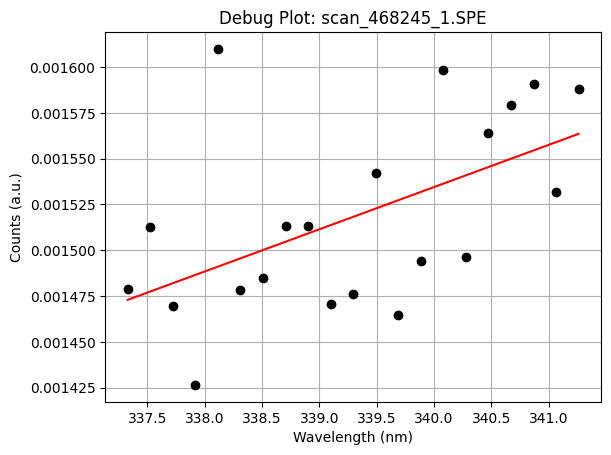

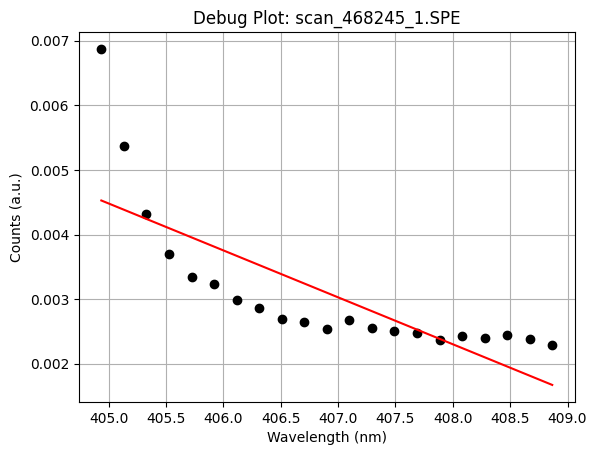

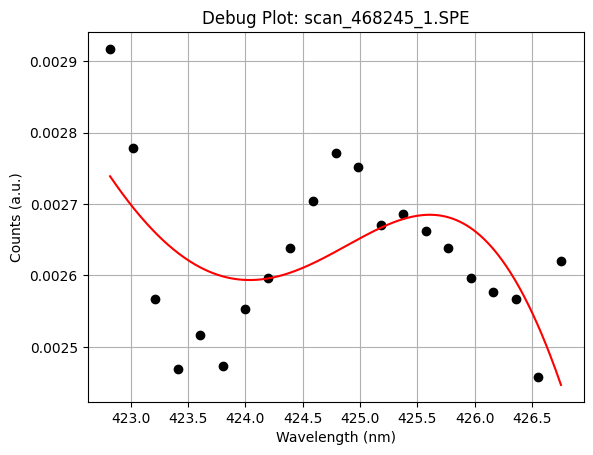

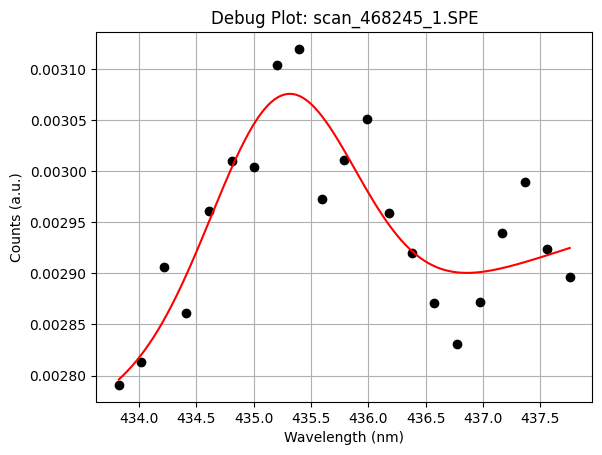

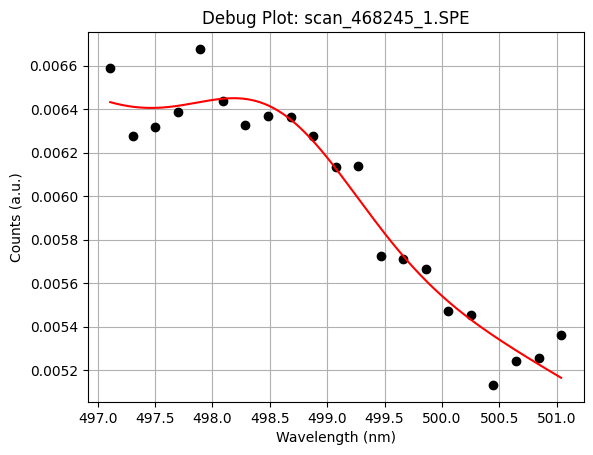

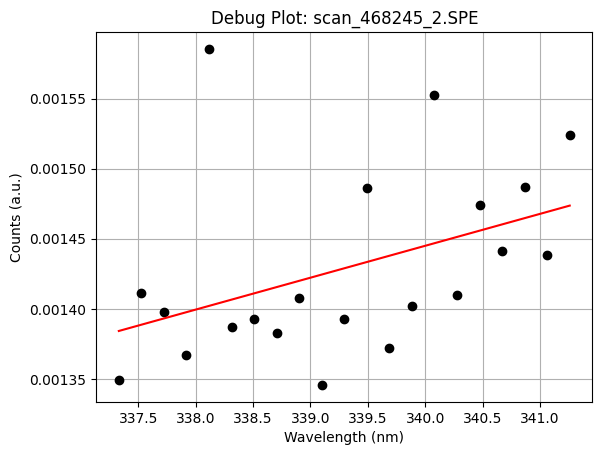

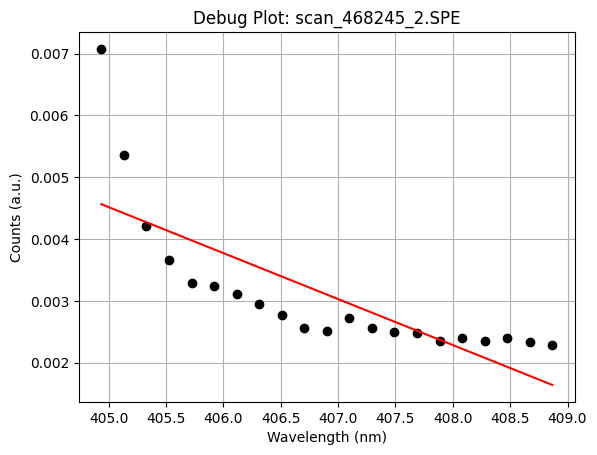

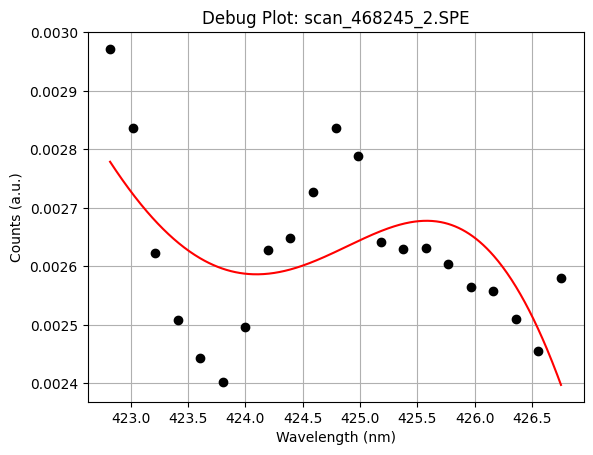

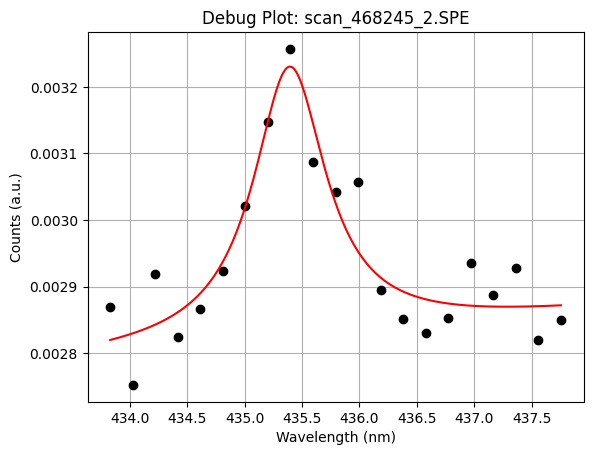

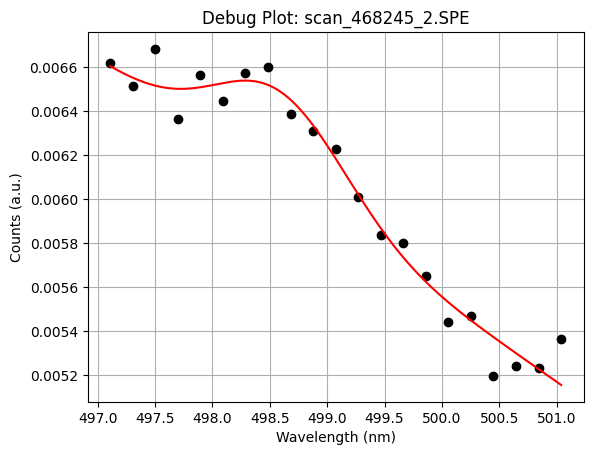

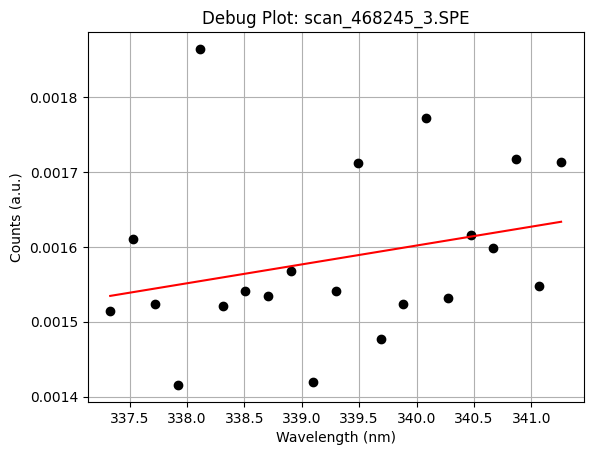

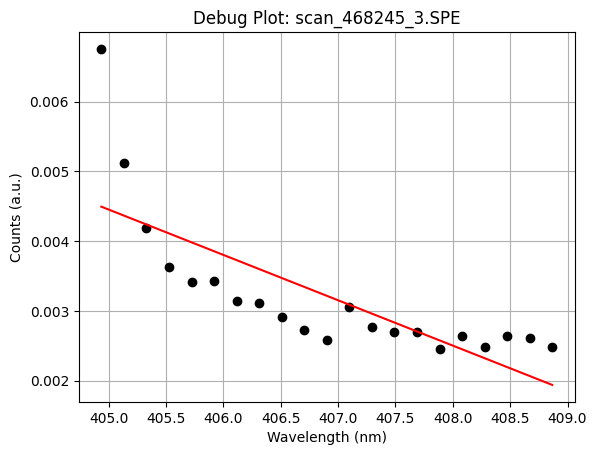

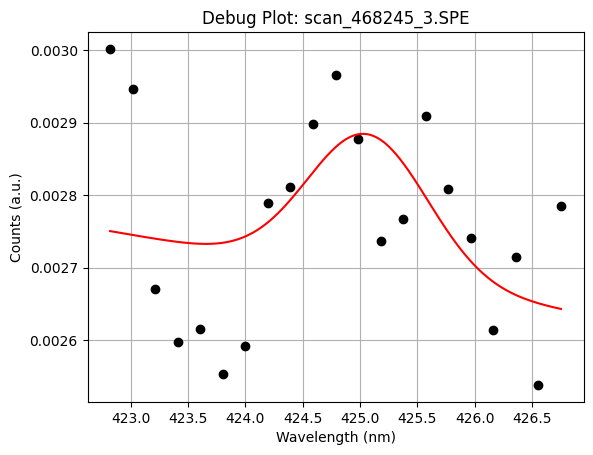

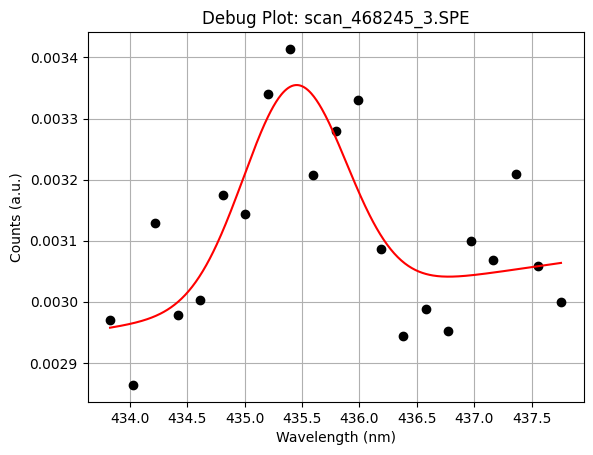

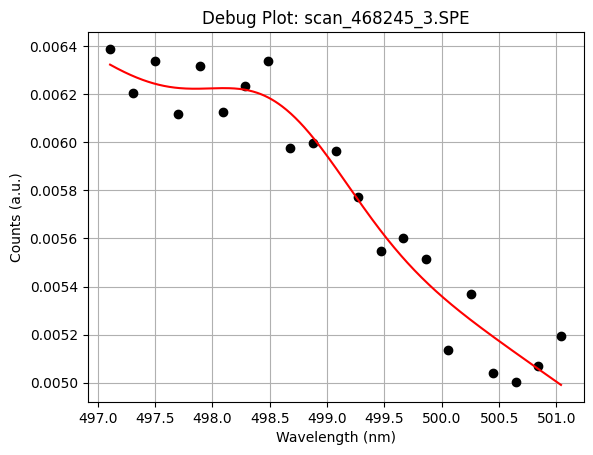

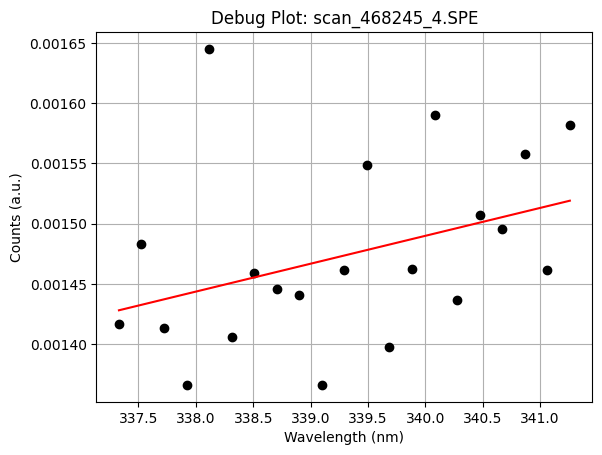

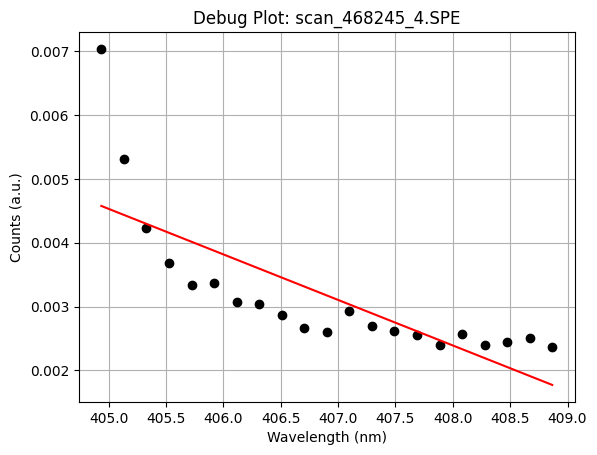

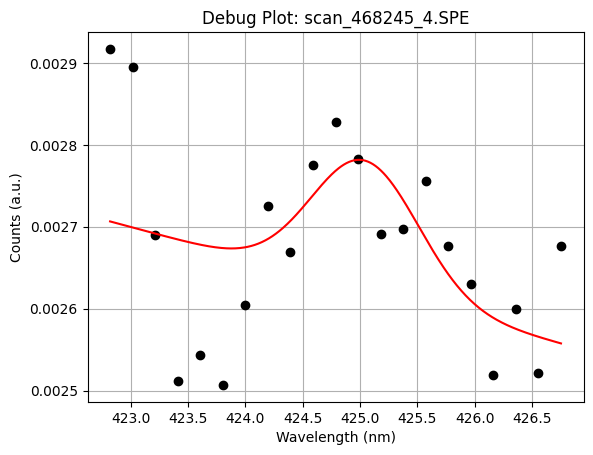

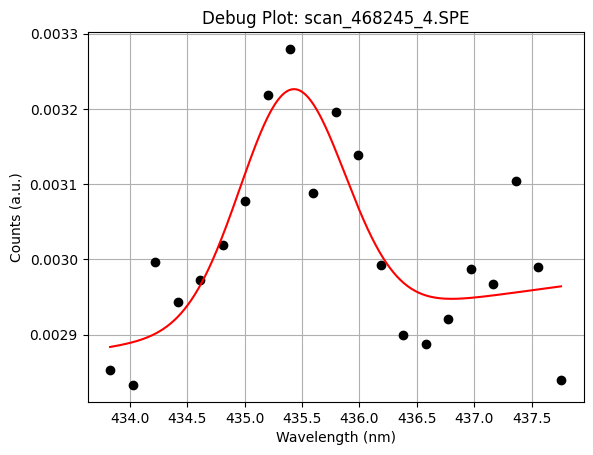

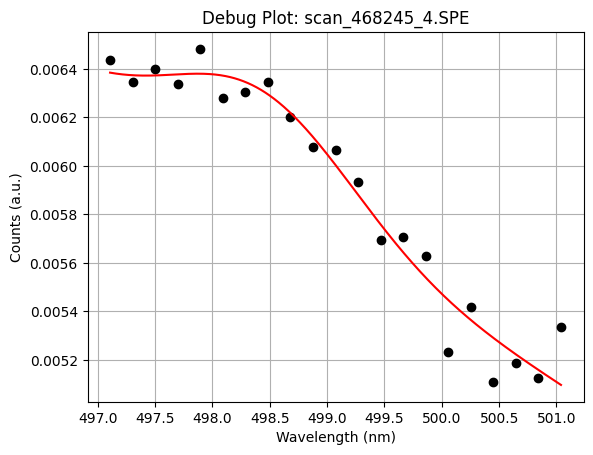

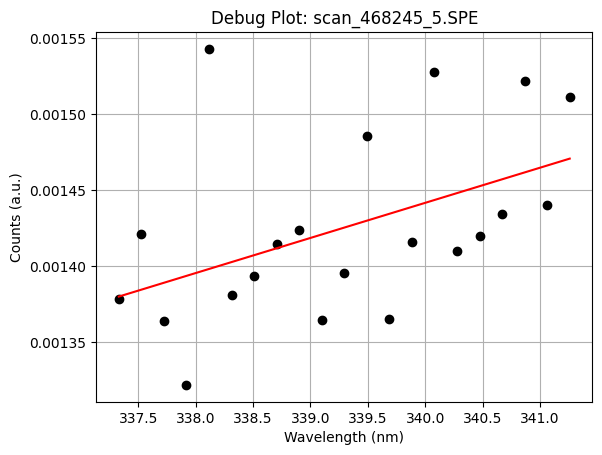

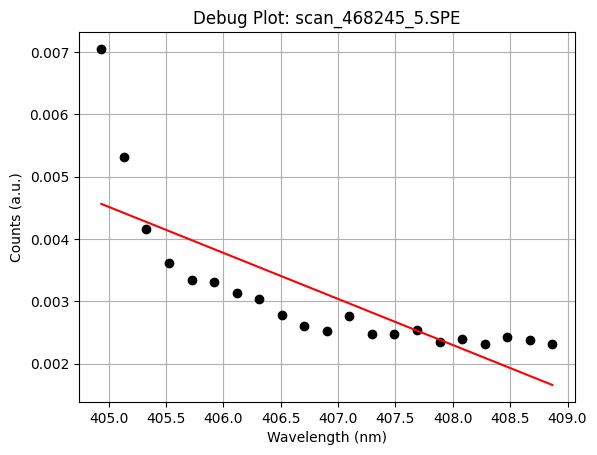

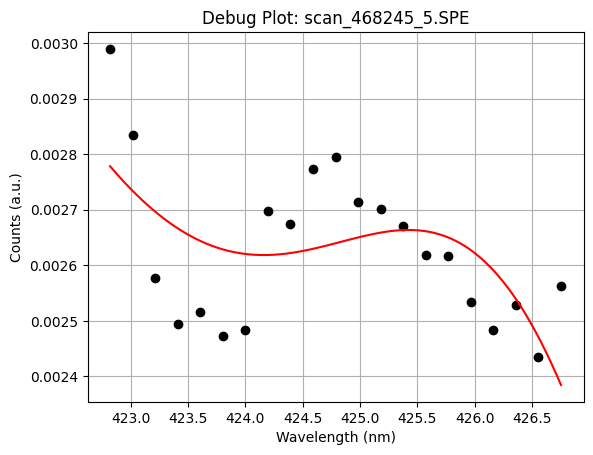

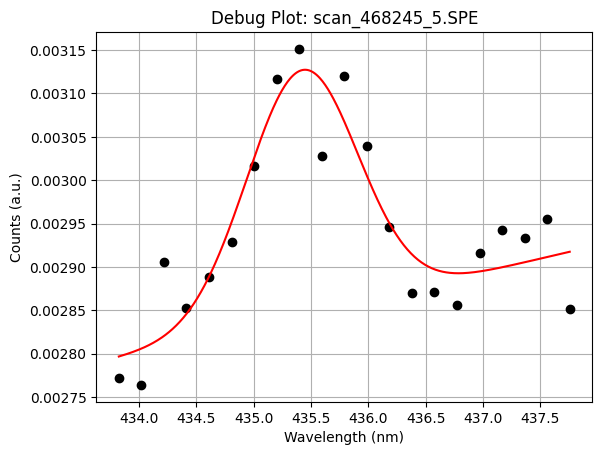

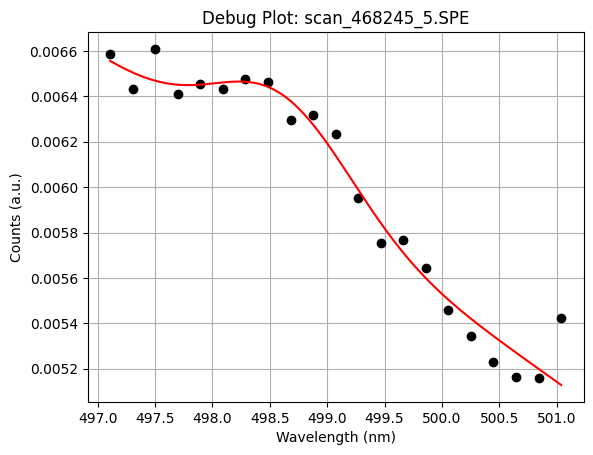

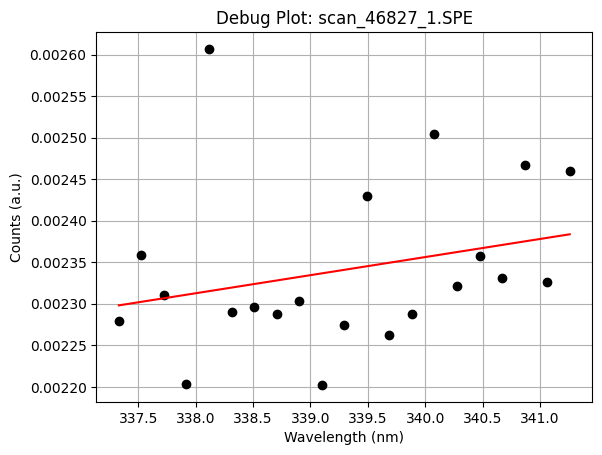

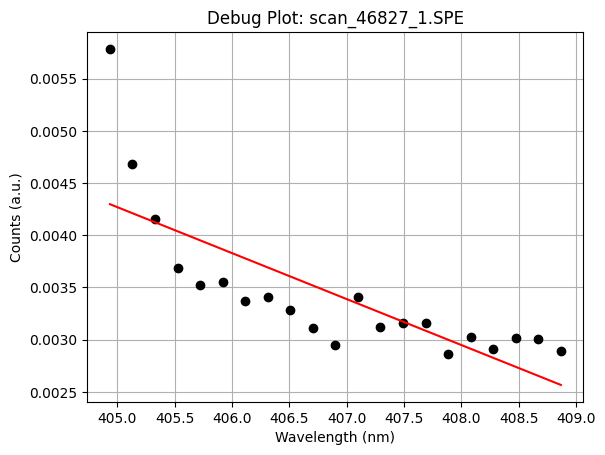

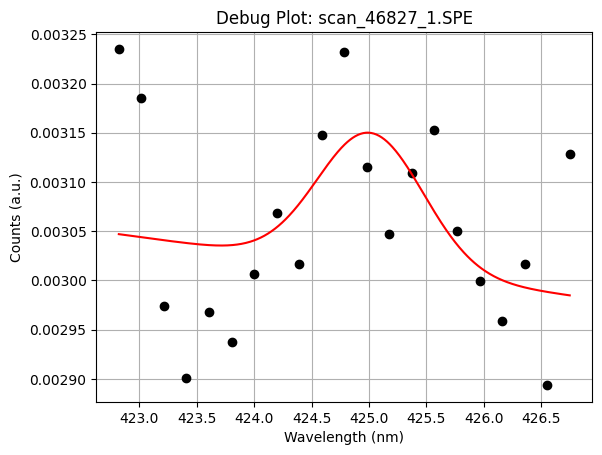

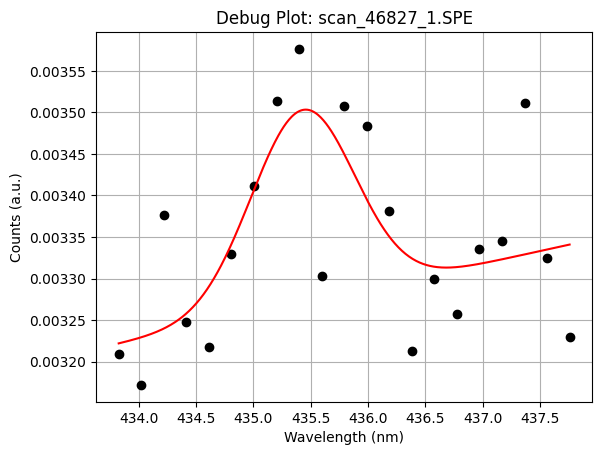

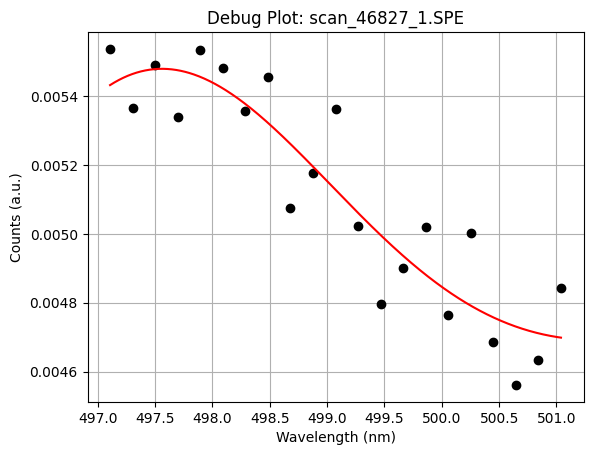

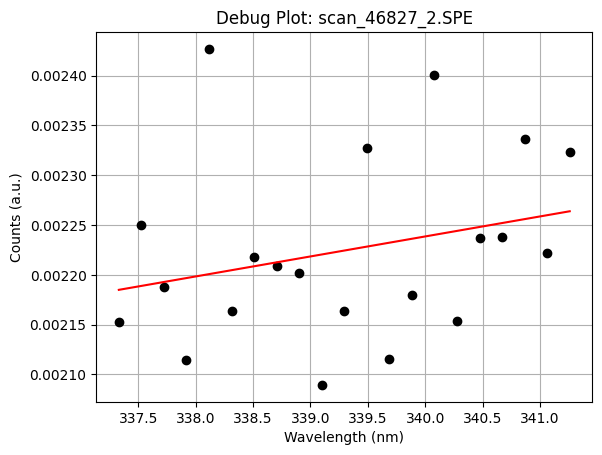

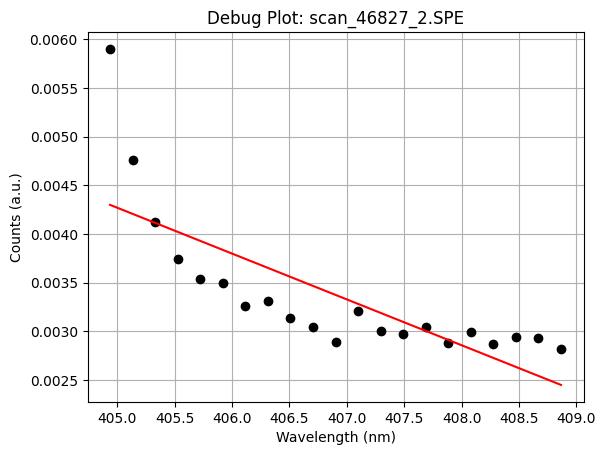

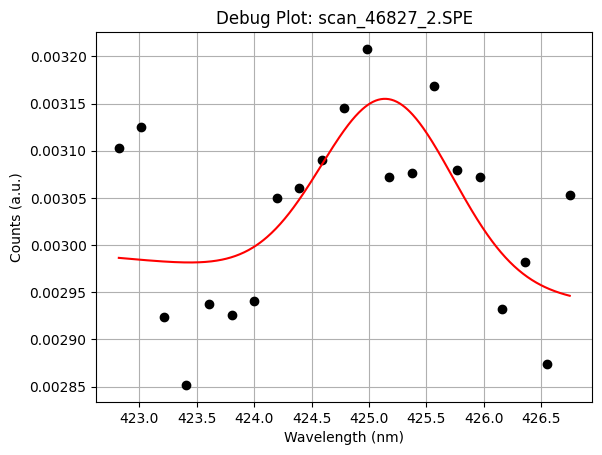

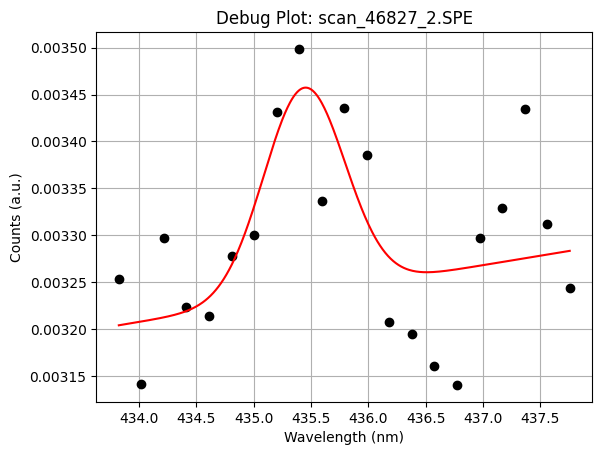

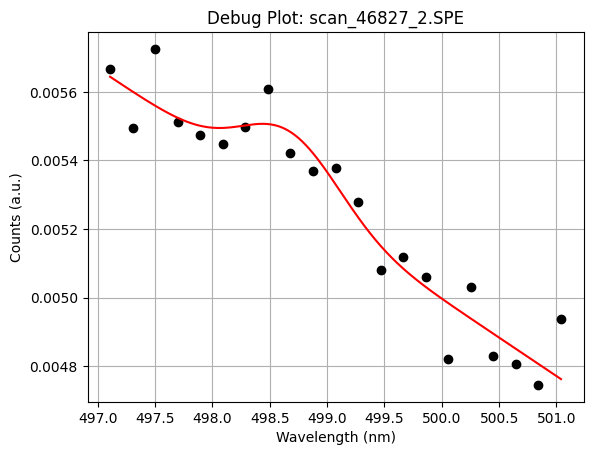

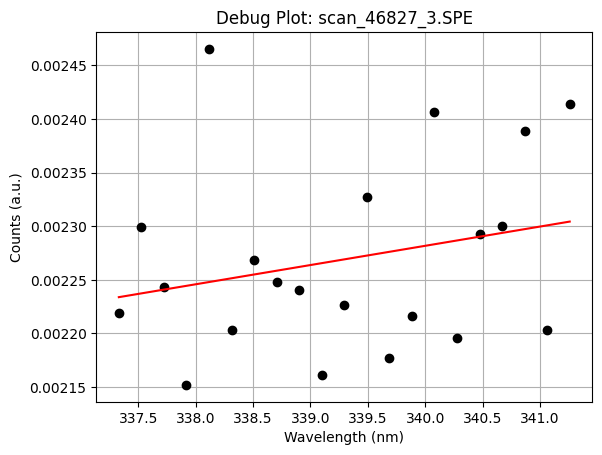

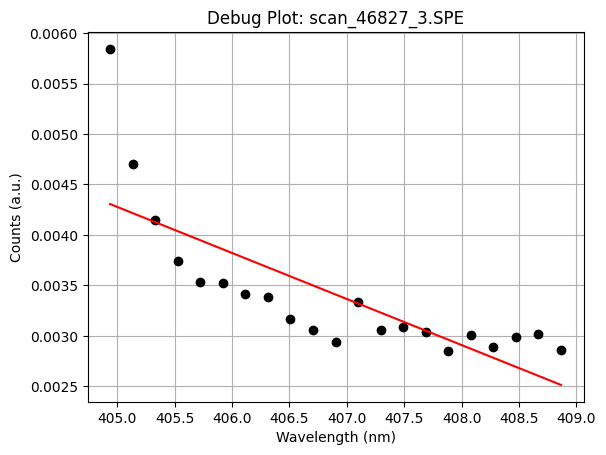

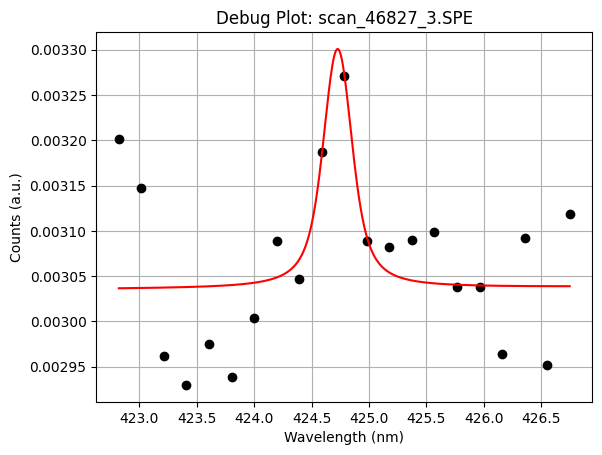

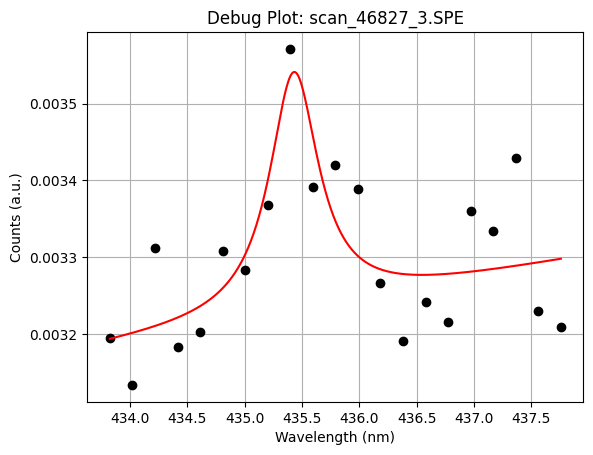

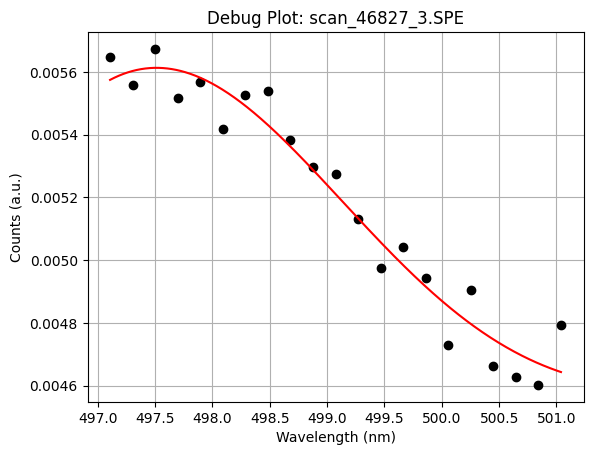

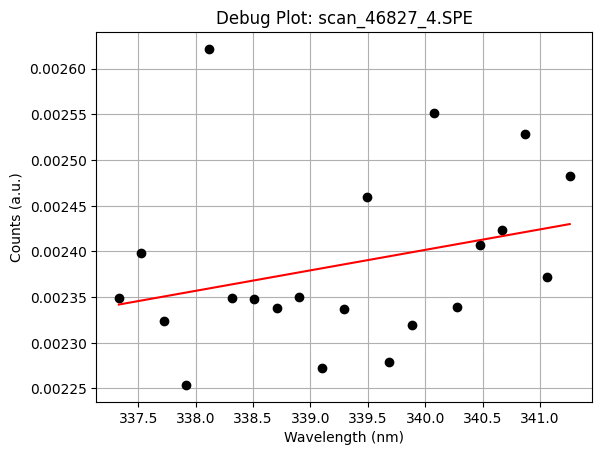

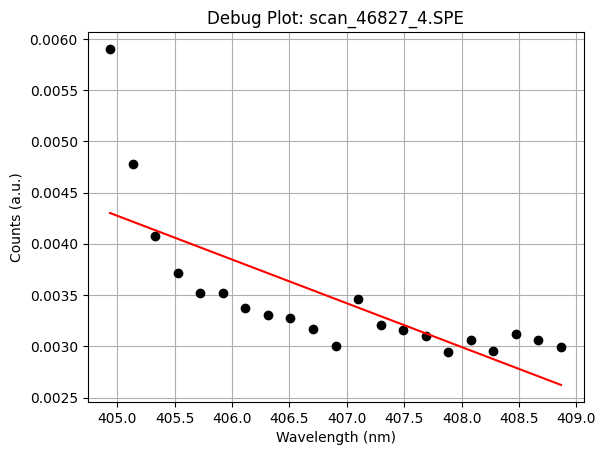

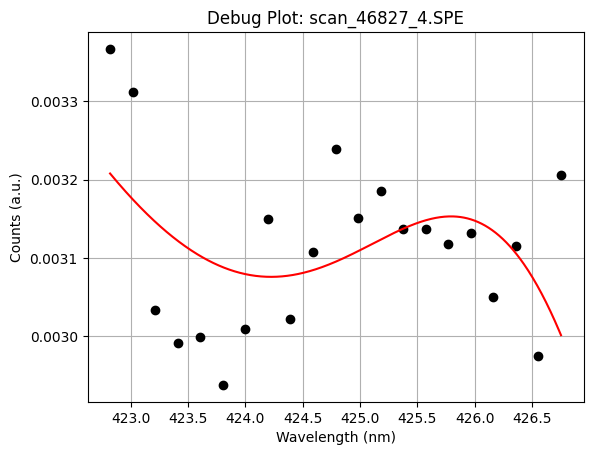

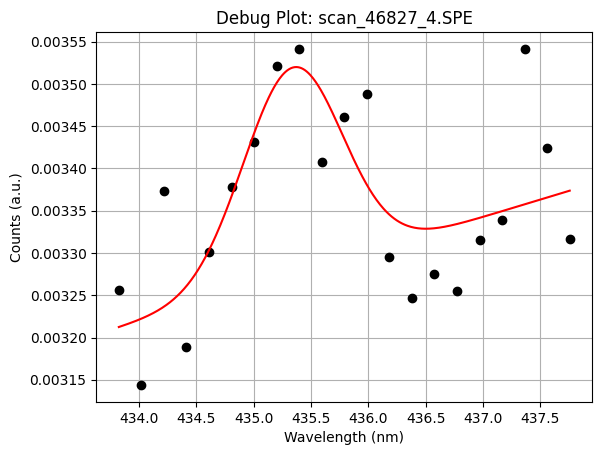

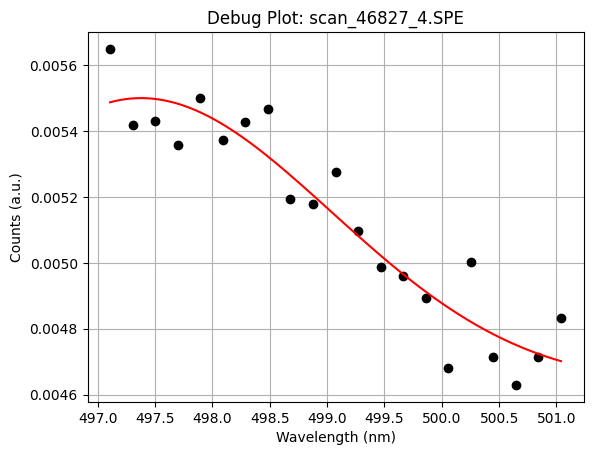

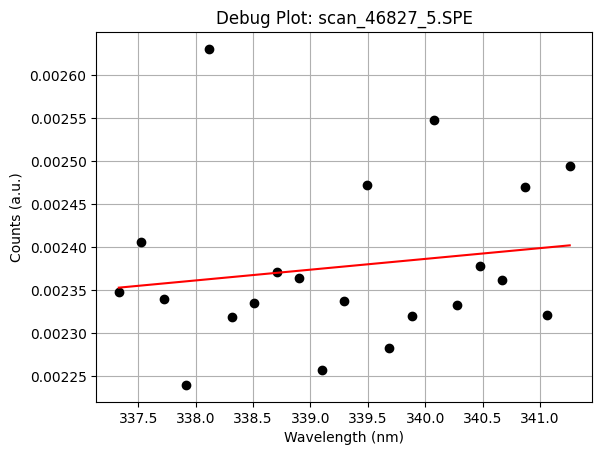

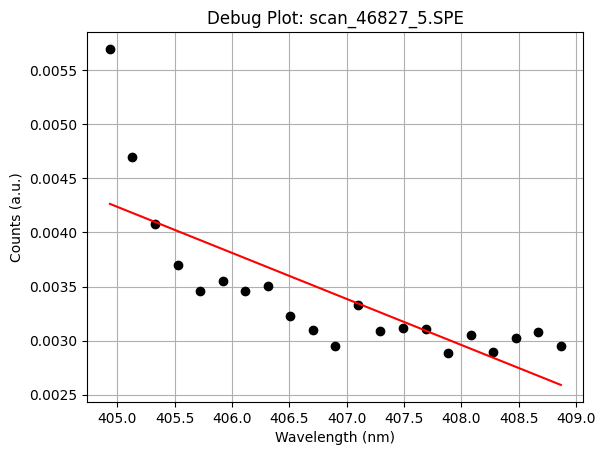

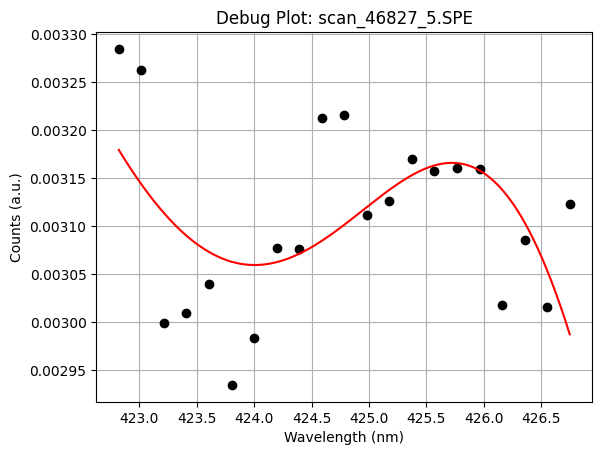

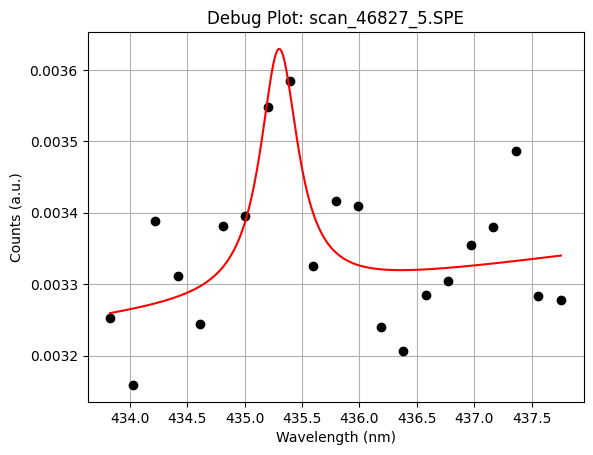

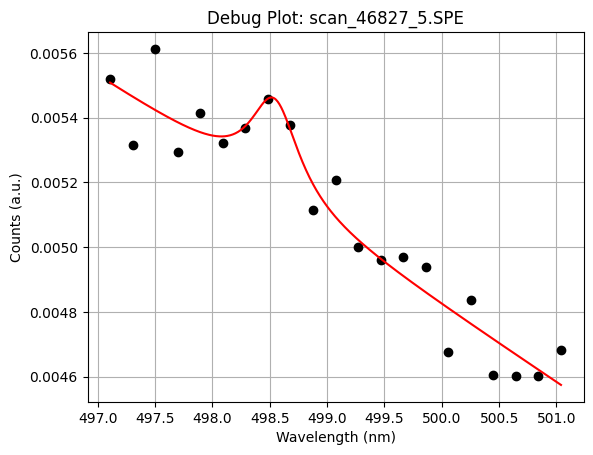

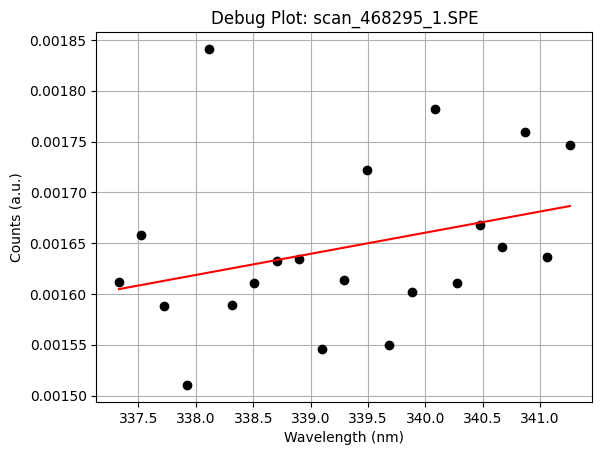

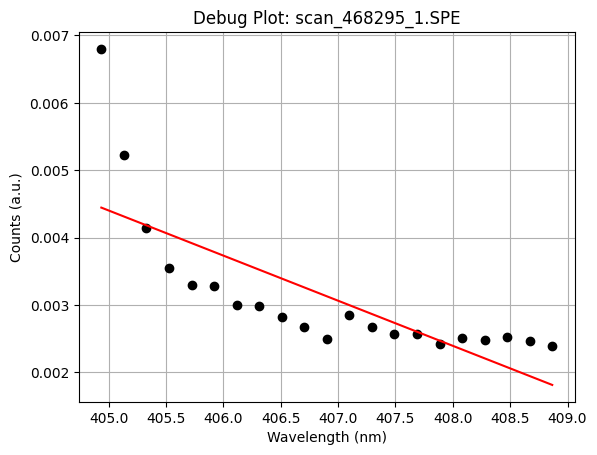

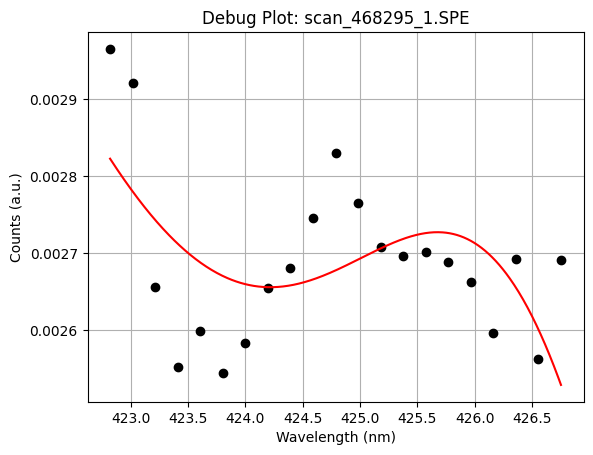

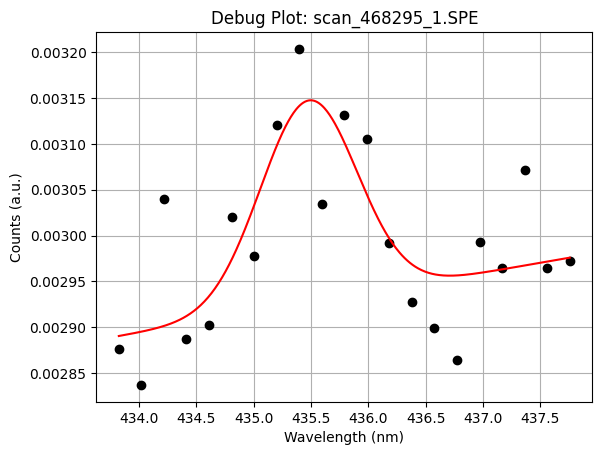

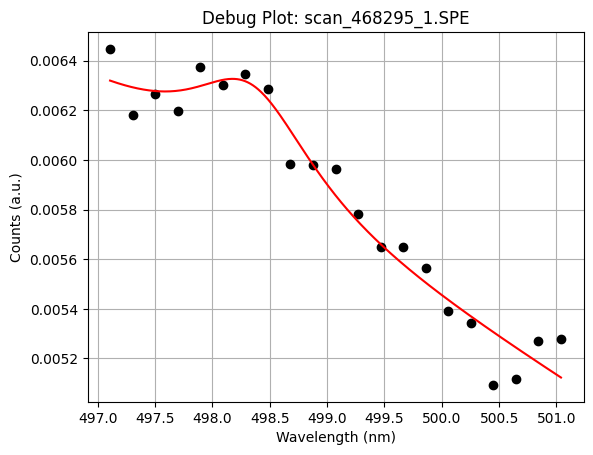

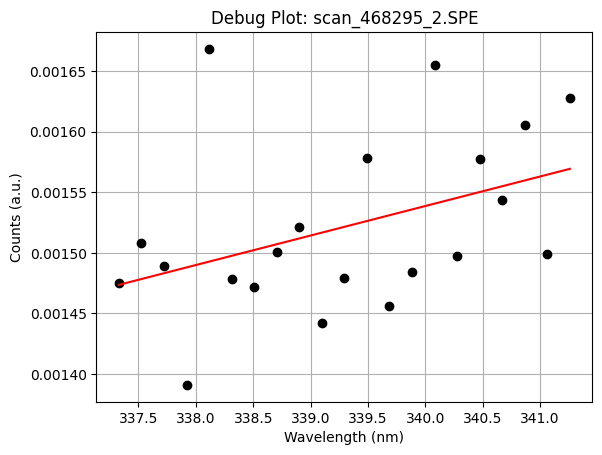

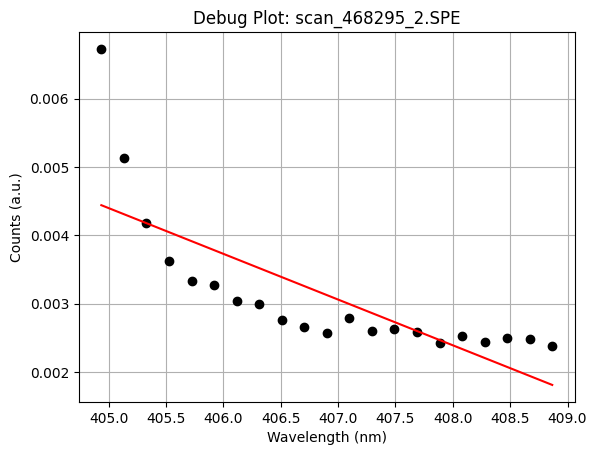

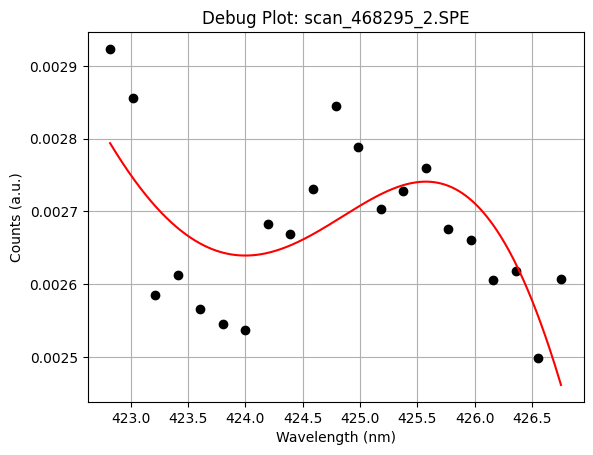

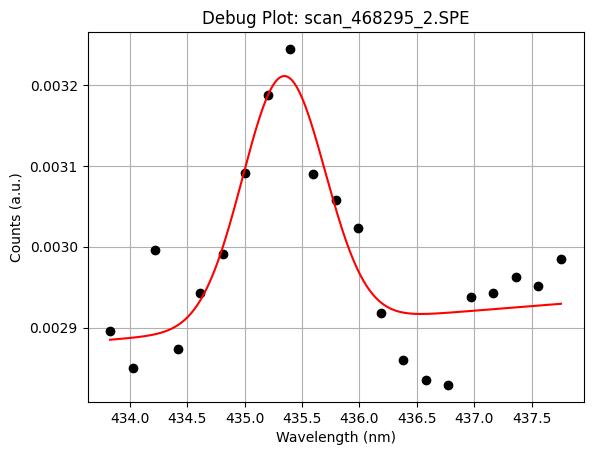

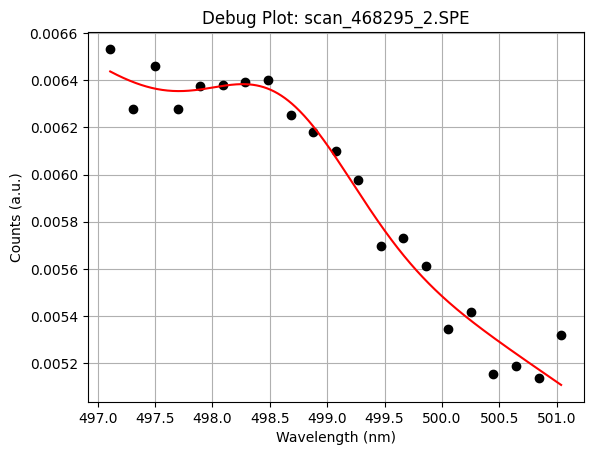

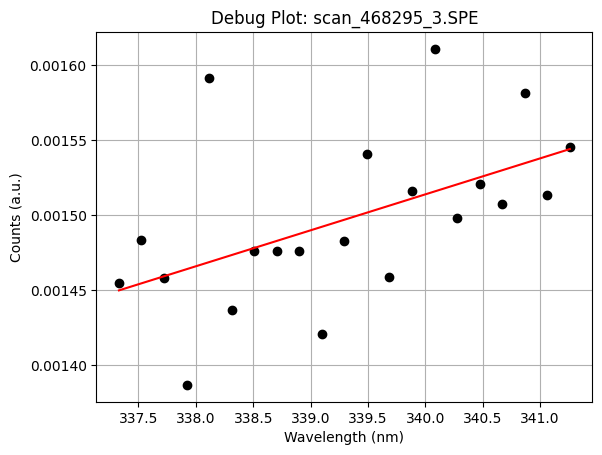

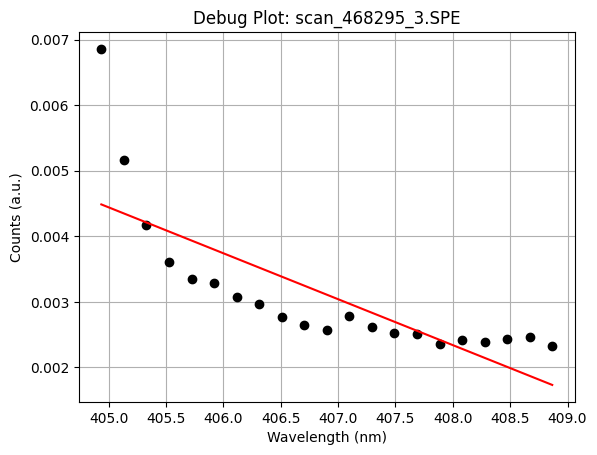

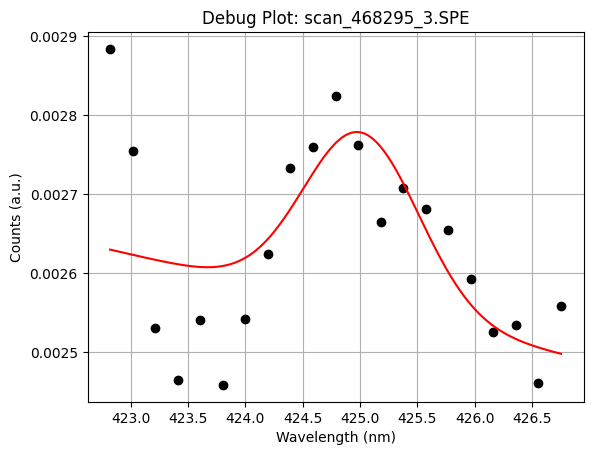

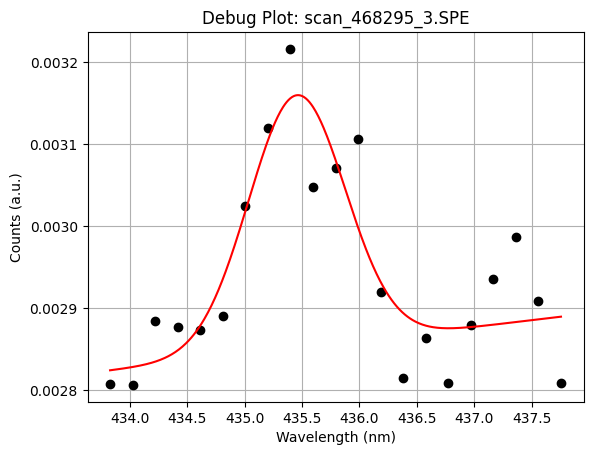

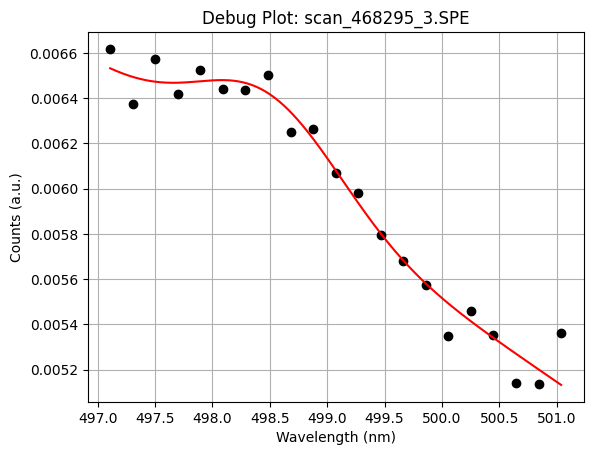

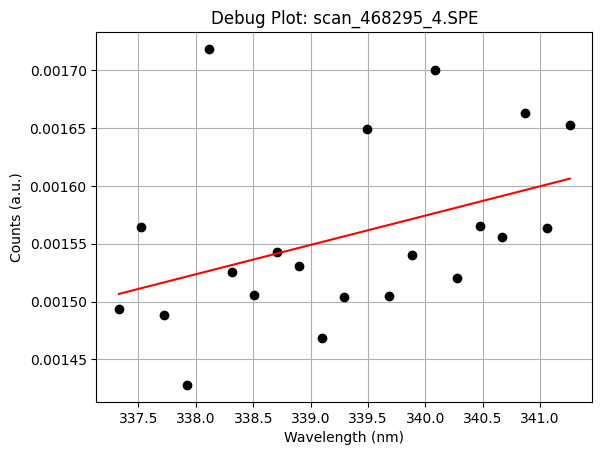

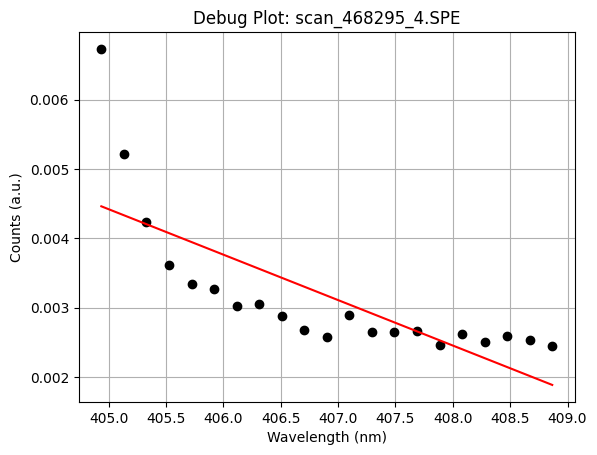

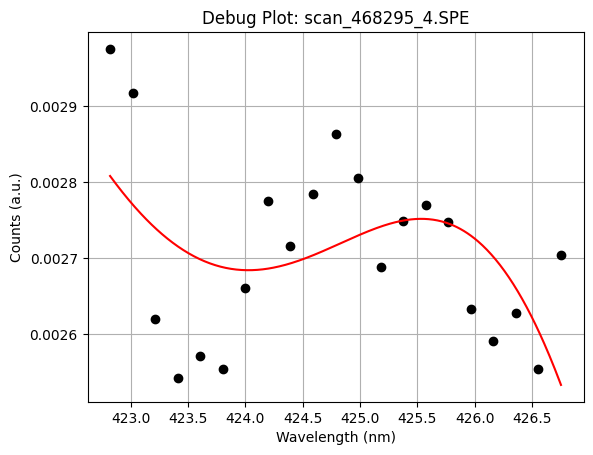

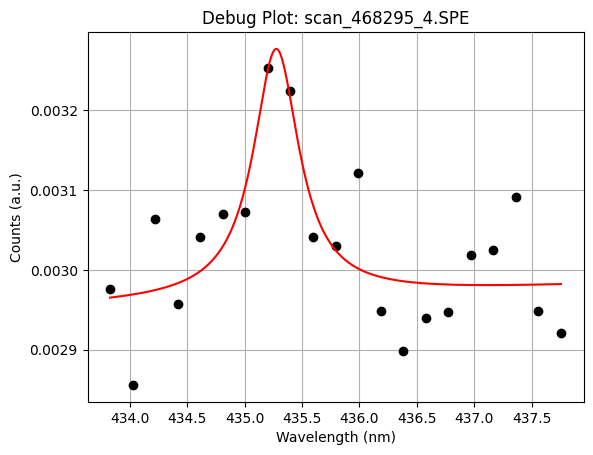

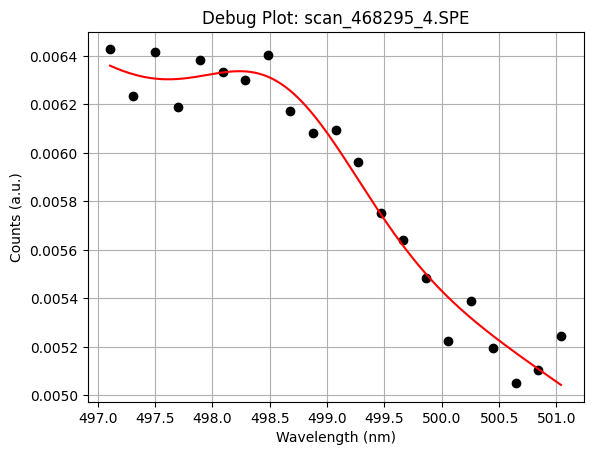

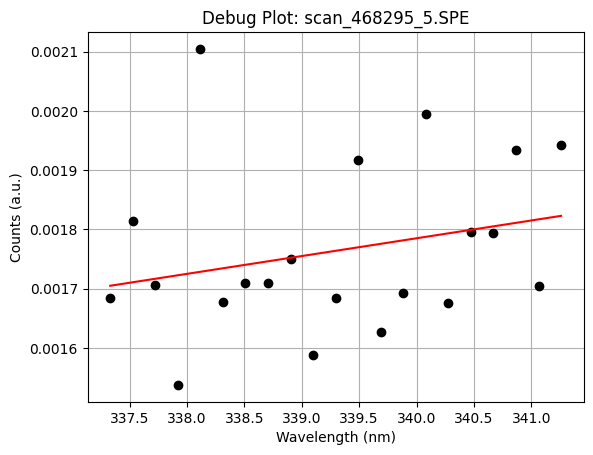

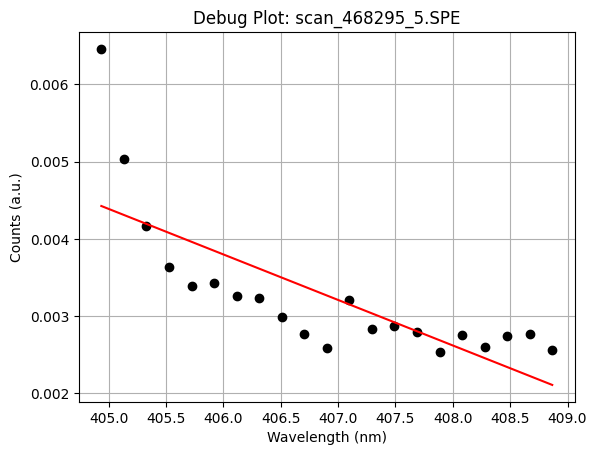

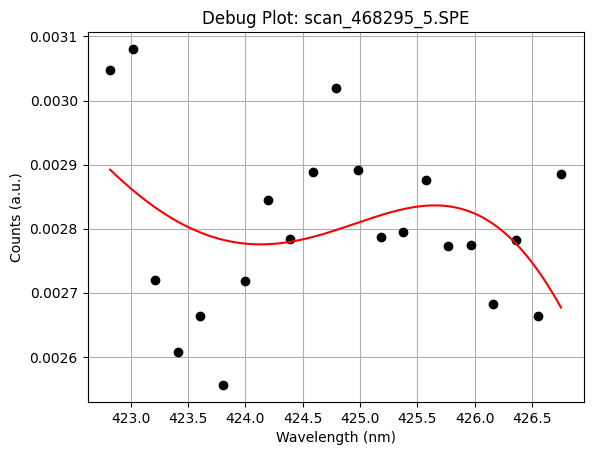

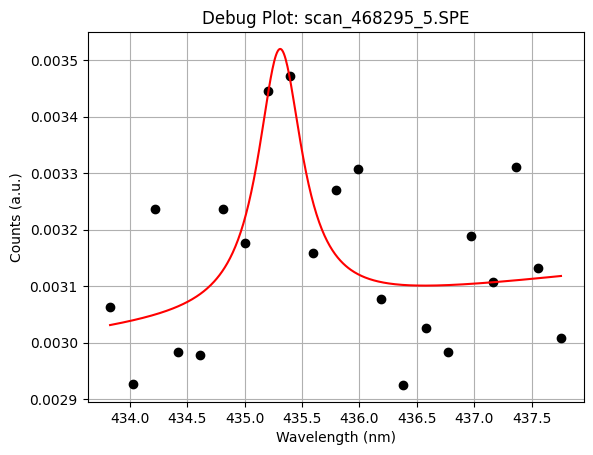

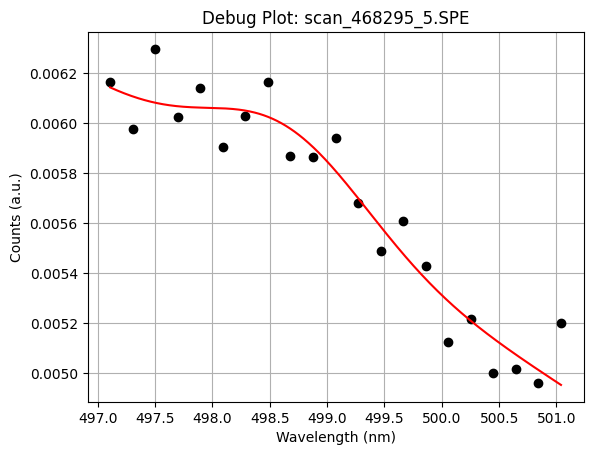

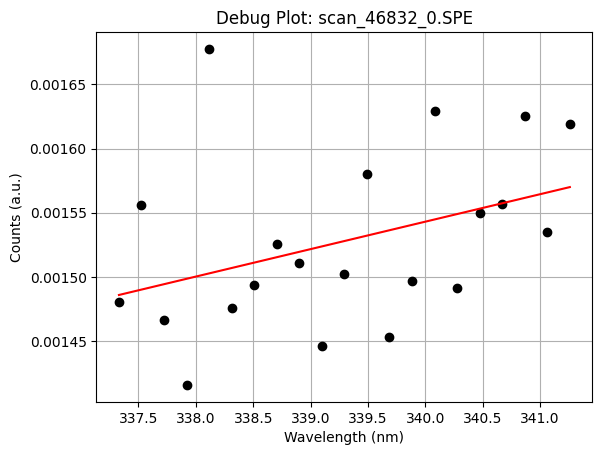

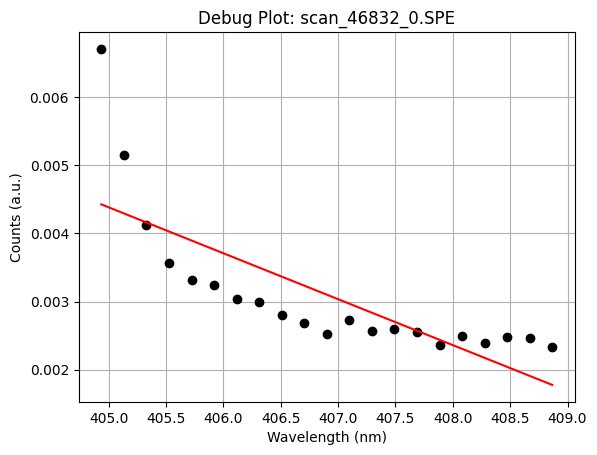

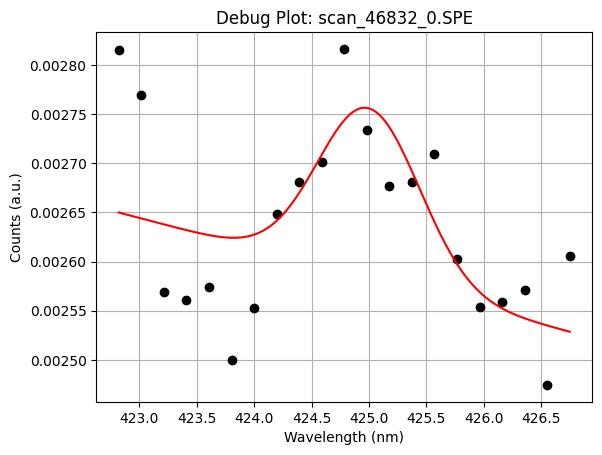

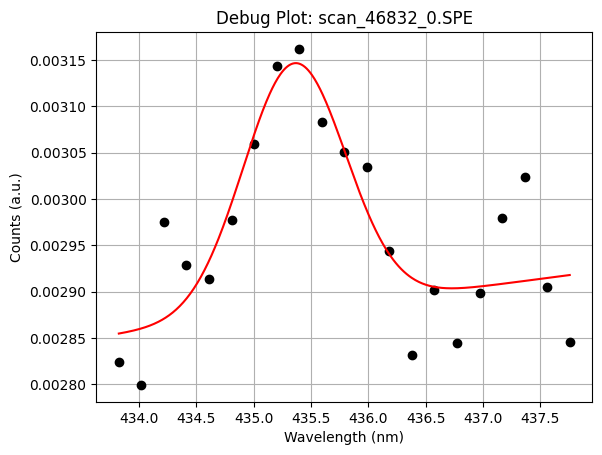

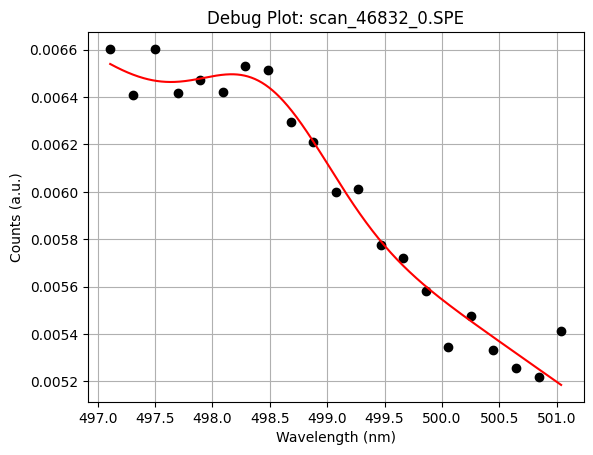

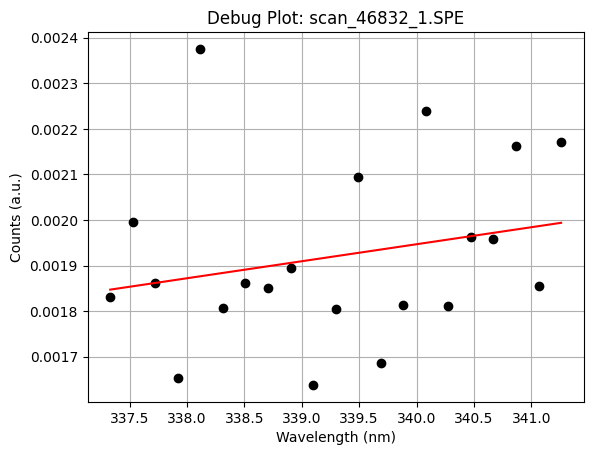

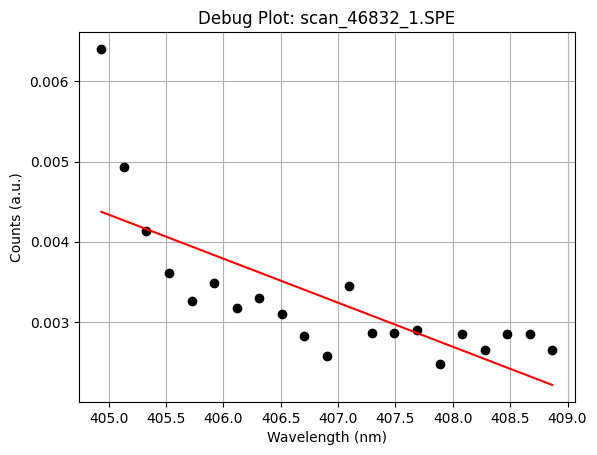

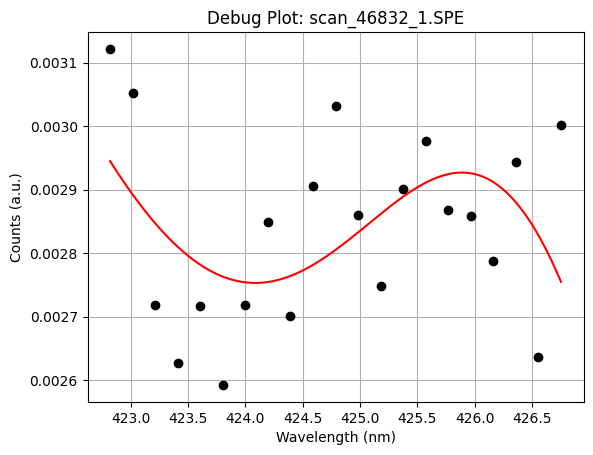

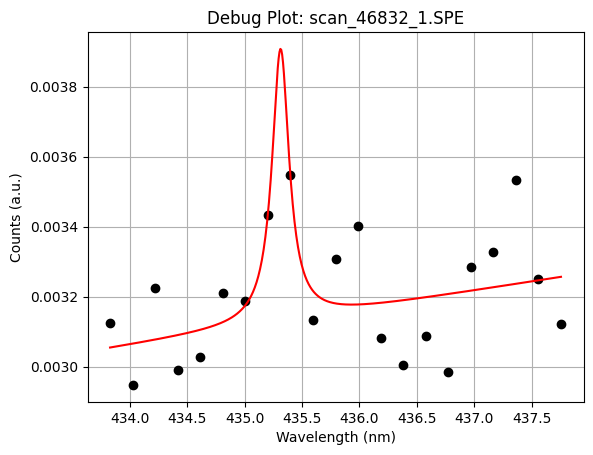

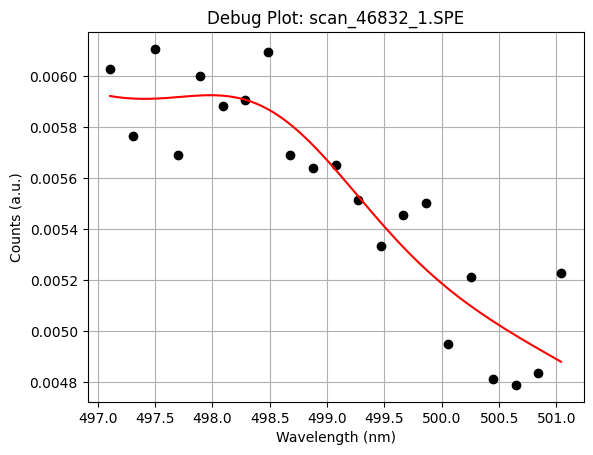

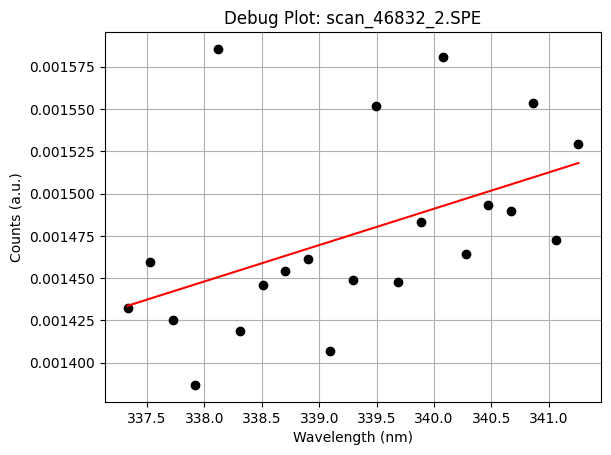

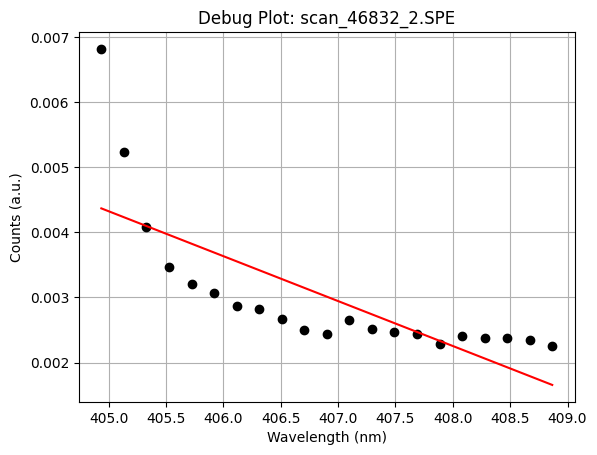

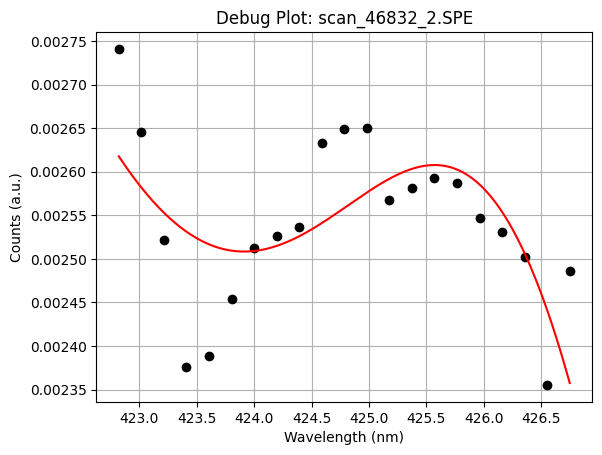

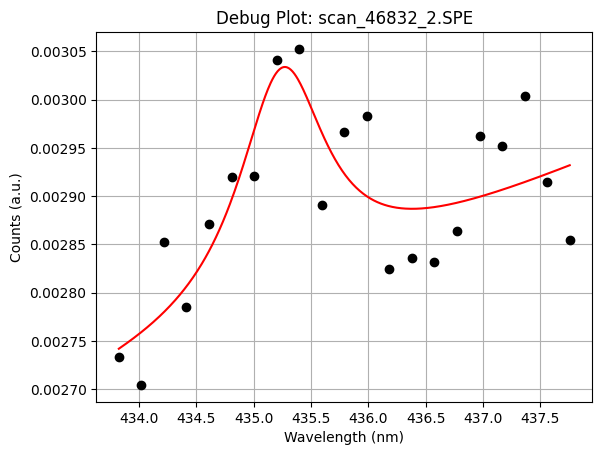

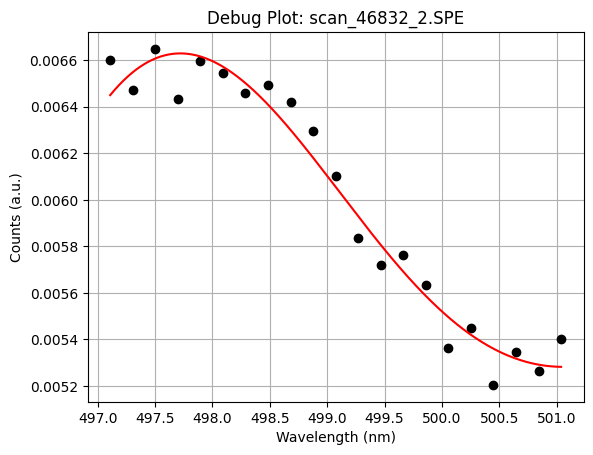

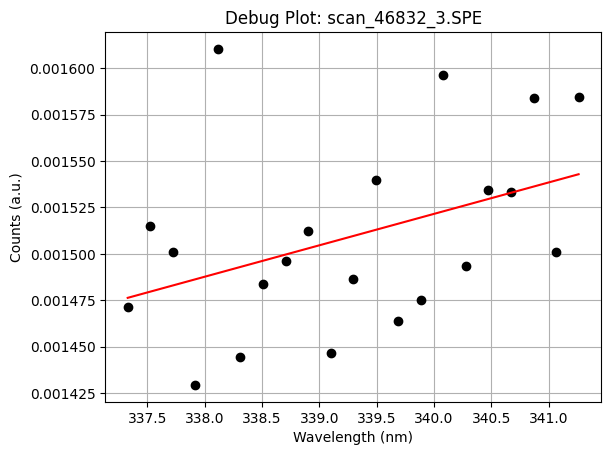

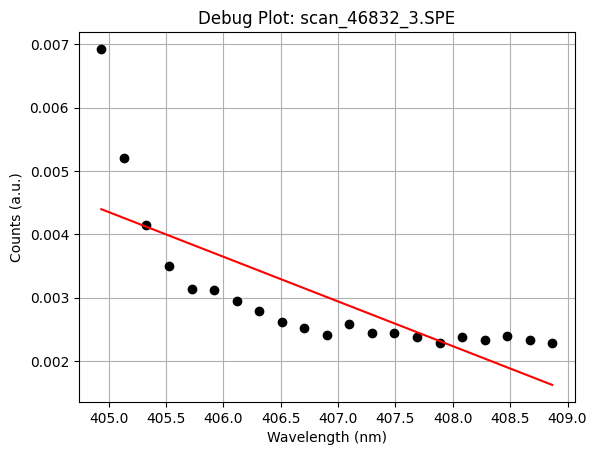

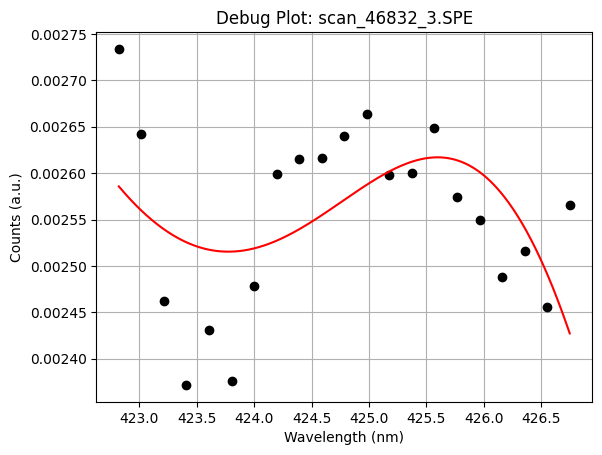

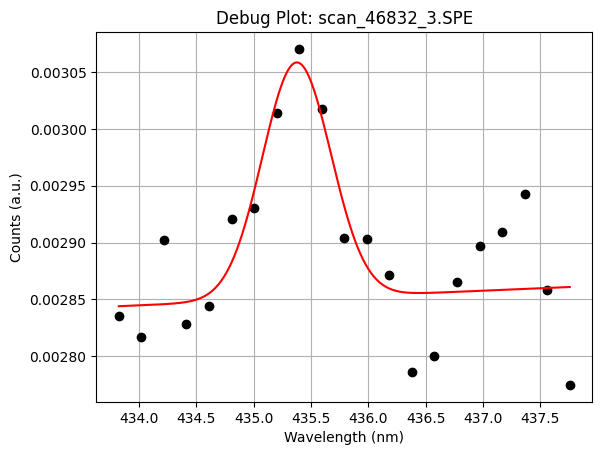

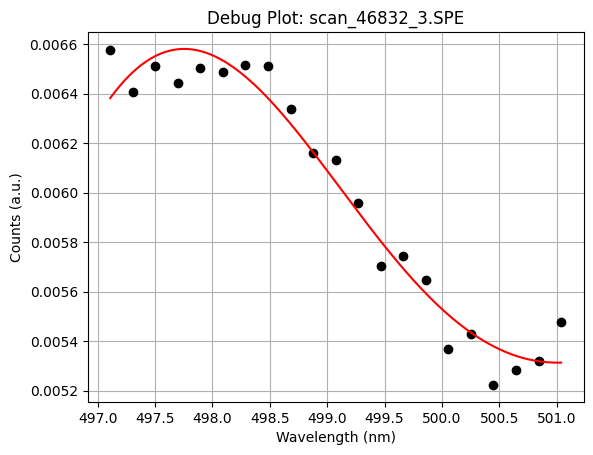

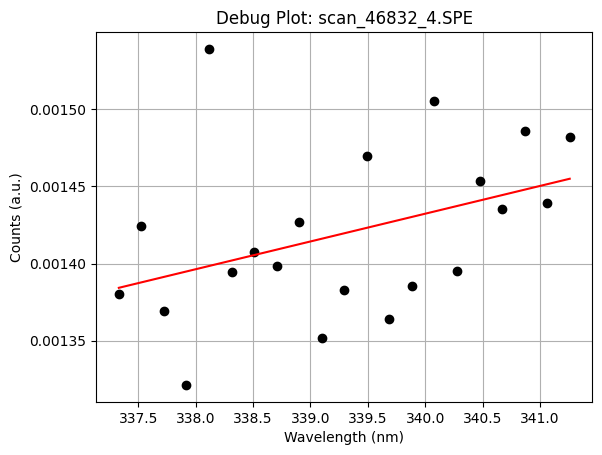

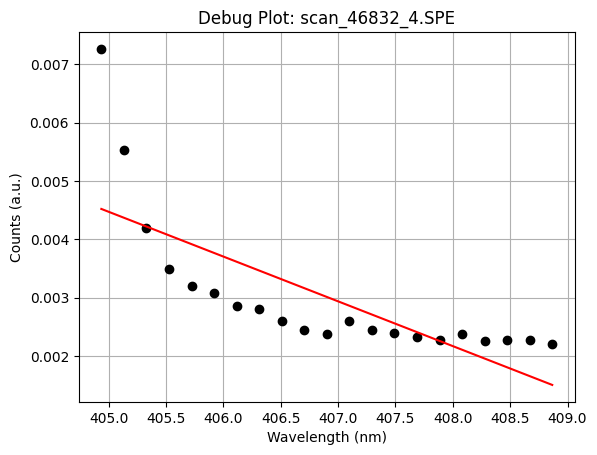

Error in callback <function flush_figures at 0x000001D4E185A4B0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [44]:
N_points = 21
N_fit = 512
fit_method = "voigt"
maxfev = 5000
r2_limit = 0.5
debug = False

fit_results_path = os.path.join(results_path, "Peak Fit")
os.makedirs(fit_results_path, exist_ok = True)

fit_param_names = {
    "gaussian":   ["A", "mu", "sigma", "a", "b"],
    "lorentzian": ["A", "mu", "gamma", "a", "b"],
    "voigt":      ["A", "mu", "sigma", "gamma", "a", "b"],
}


for file in results.keys():
    print("=" * 50)
    print(f"Fitting: {file}")
    print("=" * 50)
    data = results[file]

    x_full = data["wavelength"]
    y_full = data["spectrum"]
    areas = []
    intensities = []
    r2s = []

    for _, line in lines_df.iterrows():
        lamb0 = line["wavelength"]
        intensity = line["intensity_numeric"]

        idx = np.argmin(np.abs(x_full - lamb0))
        start = idx - N_points // 2
        end = idx + N_points // 2 + 1
        x = x_full[start : end]
        y = y_full[start : end]

        p0 = initial_guess(x, y, mode = fit_method)
        bounds = set_bounds(x, y, p0, mode = fit_method)

        if fit_method == "gaussian":
            fit_func = gaussian_fit

        elif fit_method == "lorentzian":
            fit_func = lorentzian_fit

        elif fit_method == "voigt":
            fit_func = voigt_fit

        try:
            params, pcov = curve_fit(fit_func, x, y, p0 = p0, bounds = bounds, maxfev = maxfev)
            x_fit = np.linspace(x.min(), x.max(), N_fit)
            y_fit = fit_func(x_fit, *params)

        except Exception as e:
            print(f"An error occurred: {e}")

            fig, ax = plt.subplots(1)
            ax.plot(x, y, "o")
            ax.grid(True)
            ax.set_xlabel("Wavelength (nm)")
            ax.set_ylabel("Counts (a.u.)")
            ax.set_title(f"Failed Fit: {file}")
            plt.show()
            continue

        
        fig, ax = plt.subplots(1)
        ax.plot(x, y, "o", color = "black")
        ax.plot(x_fit, y_fit, color = "red")
        ax.grid(True)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Counts (a.u.)")
        ax.set_title(f"Debug Plot: {file}")

        if debug:
            scan_wavelength = data["scan_wavelength"]
            figure_file = os.path.join(fit_results_path, f"peak_fit_{round(scan_wavelength, 2)}_{round(lamb0, 2)}_{method}.png")
            fig.savefig(figure_file)

        x_fit = np.linspace(x.min(), x.max(), N_points)
        y_fit = fit_func(x_fit, *params)
        r2 = compute_r2(y, y_fit)

        if r2 > r2_limit:
            areas.append(intensity * compute_area(params, mode = fit_method))
            intensities.append(intensity)
            r2s.append(r2 * intensity)

    areas = np.array(areas)
    area = np.sum(areas) / np.sum(intensities)
    R2 = np.sum(r2s) / np.sum(intensities)


    results[file]["area"] = area
    results[file]["R2"] = R2

    print(f"R^2: {round(r2, 3)}")

    for name, value in zip(fit_param_names[fit_method], params):
        print(f"{name}: {round(value, 3)}")
        results[file][name] = value
    
    print(f"area: {round(area, 3)}")
    print("=" * 50)

c:\Users\kpspe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kpspe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


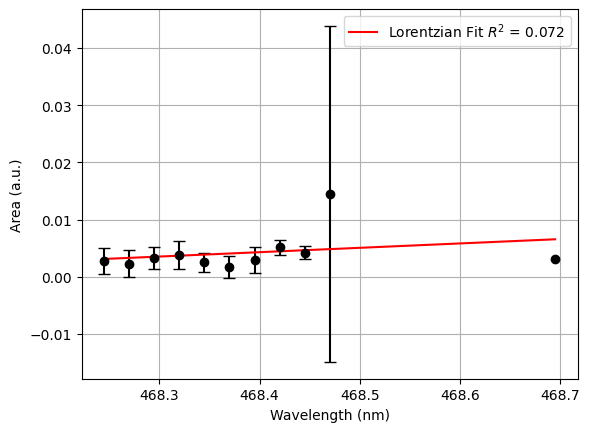

In [ ]:
areas = np.array([results[file]["area"] for file in results.keys()])
scan_wavelengths = np.array([results[file]["scan_wavelength"] for file in results.keys()])
r2_values = np.array([results[file]["R2"] for file in results.keys()])

unique_scan_wavelengths, indexes = np.unique(scan_wavelengths, return_inverse = True)
mean_areas = np.array([np.mean(areas[indexes == i]) for i in range(len(unique_scan_wavelengths))])
std_areas = np.array([np.std(areas[indexes == i], ddof = 1) for i in range(len(unique_scan_wavelengths))])

params, _ = curve_fit(lorentzian_fit, unique_scan_wavelengths, mean_areas, maxfev = 1000000)

areas_fit = lorentzian_fit(unique_scan_wavelengths, *params)
r2 = compute_r2(mean_areas, areas_fit)

fig, ax = plt.subplots(1)
ax.errorbar(unique_scan_wavelengths, mean_areas, yerr = std_areas, fmt = "o", capsize = 4, color = "black")
ax.plot(unique_scan_wavelengths, areas_fit, color = "red", label = f"Lorentzian Fit $R^2$ = {round(r2, 3)}")

ax.grid(True)
ax.legend()
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Area (a.u.)")
plt.show()